# Clase 1 · Laboratorio — Explorando Saber 11

**Trabajo en parejas · 90 min.**

Al final deben tener un notebook completado con las 5 tareas resueltas y subirlo a Moodle antes de las 23:59 del día de clase.

**Checkpoint conjunto a los 45 min:** el profesor detiene la sala y resolvemos juntos cualquier duda de la Tarea 3. Sigan al ritmo del reloj.

In [1]:
#!pip3 install --user pyarrow  # ya lo instalé la clase pasada, lo dejo comentado
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../saber11_muestra_500k.csv")
print(f"Cargados {len(df):,} registros")
df.head()

Cargados 500,000 registros


,PERIODO,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_DEPTO_RESIDE,ESTU_MCPIO_RESIDE,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,COLE_NATURALEZA,...,COLE_BILINGUE,COLE_DEPTO_UBICACION,COLE_MCPIO_UBICACION,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,PUNT_GLOBAL,DESEMP_INGLES
0,20194,M,20/10/2003,ATLÁNTICO,BARRANQUILLA,2,No,Educación profesional completa,Ninguno,OFICIAL,...,N,ATLÁNTICO,BARRANQUILLA,48,51,26,14,67,194,A2
1,20224,F,10/12/2002,BOLÍVAR,CARTAGENA,1,Si,Educación profesional incompleta,Técnica o tecnológica incompleta,OFICIAL,...,N,BOLÍVAR,CARTAGENA,77,32,64,48,48,199,A-
2,20214,F,18/04/2004,BOGOTÁ D.C.,BOGOTÁ D.C.,3,Si,Ninguno,Educación profesional incompleta,NO OFICIAL,...,N,BOGOTÁ D.C.,BOGOTÁ D.C.,65,43,63,84,48,268,A-
3,20204,F,16/02/2000,NARIÑO,PASTO,4,Si,Primaria incompleta,Postgrado,OFICIAL,...,N,NARIÑO,PASTO,61,45,52,62,49,365,A1
4,20204,F,18/02/2002,BOLÍVAR,CARTAGENA,5,NaN,Técnica o tecnológica incompleta,Educación profesional incompleta,OFICIAL,...,N,BOLÍVAR,CARTAGENA,68,87,52,16,57,355,A1


## Tarea 1 (10 min) — Perfil del dataset

Completa las siguientes celdas para responder:
- ¿Cuántos años cubre el dataset?
- ¿Cuál es el rango del PUNT_GLOBAL (mínimo, máximo, media)?
- ¿Qué porcentaje de estudiantes viene de colegios oficiales vs no oficiales?

In [2]:
# años cubiertos
# PERIODO viene como 20194, 20204... los primeros 4 digitos son el año
anos = df["PERIODO"].astype(str).str[:4].unique()
print(sorted(anos))

['2019', '2020', '2021', '2022']


In [3]:
# rango de PUNT_GLOBAL
resumen_punt = df["PUNT_GLOBAL"].describe()
print(resumen_punt)

count    500000.000000
mean        248.647070
std          53.926421
min           0.000000
25%         212.000000
50%         248.000000
75%         285.000000
max         500.000000
Name: PUNT_GLOBAL, dtype: float64


In [4]:
# distribucion de COLE_NATURALEZA (en %)
distribucion_naturaleza = df["COLE_NATURALEZA"].value_counts(normalize=True) * 100
print(distribucion_naturaleza.round(2))

COLE_NATURALEZA
OFICIAL       71.98
NO OFICIAL    28.02
Name: proportion, dtype: float64


**Respuesta Tarea 1:**

El dataset cubre 4 años: 2019, 2020, 2021 y 2022 (según el PERIODO, que es como un código año+semestre).

El PUNT_GLOBAL va de 0 a 500, con una media de 248.6 puntos, que tiene sentido porque el ICFES dice que el puntaje global va de 0 a 500.

Casi el 72% de los estudiantes de la muestra vienen de colegios oficiales (públicos) y el 28% de colegios no oficiales (privados).

## Tarea 2 (15 min) — Comparación por estrato

Produce una gráfica que compare la distribución de `PUNT_GLOBAL` entre los estratos de vivienda. Elige el tipo de gráfica más adecuado y justifica tu elección en Markdown debajo.

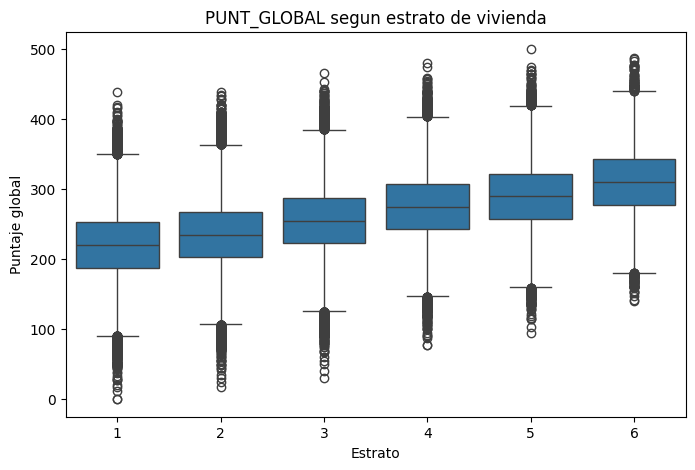

In [5]:
# grafica comparativa: boxplot de PUNT_GLOBAL por estrato
plt.figure(figsize=(8, 5))
orden_estratos = sorted(df["FAMI_ESTRATOVIVIENDA"].dropna().unique())
sns.boxplot(data=df, x="FAMI_ESTRATOVIVIENDA", y="PUNT_GLOBAL", order=orden_estratos)
plt.title("PUNT_GLOBAL segun estrato de vivienda")
plt.xlabel("Estrato")
plt.ylabel("Puntaje global")
plt.show()

_(Justifica tu elección de gráfica acá):_

Use un boxplot porque quiero comparar varios grupos (los 6 estratos) al mismo tiempo y ver no solo el promedio sino tambien que tan dispersos estan los puntajes en cada uno. Con un boxplot se ve rapido la mediana, los cuartiles y si hay valores raros (outliers). Un grafico de barras solo mostraria el promedio y se perderia la variabilidad dentro de cada estrato.

## Tarea 3 (20 min) — Brecha urbano-rural

Crea una tabla que muestre el promedio de PUNT_GLOBAL por combinación de:
- COLE_DEPTO_UBICACION (10 departamentos con más registros)
- COLE_NATURALEZA (Oficial vs No oficial)

Comenta 2 hallazgos en 3-4 frases.

In [6]:
# Pistas: usa .groupby([...]).mean() y luego .unstack() para tabla pivote.
# Filtra a los 10 departamentos con mas registros primero.
top10 = df["COLE_DEPTO_UBICACION"].value_counts().head(10).index
tabla = (
    df[df["COLE_DEPTO_UBICACION"].isin(top10)]
    .groupby(["COLE_DEPTO_UBICACION", "COLE_NATURALEZA"])["PUNT_GLOBAL"]
    .mean()
    .unstack()
)
tabla["diferencia"] = tabla["NO OFICIAL"] - tabla["OFICIAL"]
tabla.sort_values("diferencia", ascending=False)

COLE_NATURALEZA,NO OFICIAL,OFICIAL,diferencia
COLE_DEPTO_UBICACION,,,
BOLÍVAR,249.051326,248.442964,0.608362
TOLIMA,248.715284,248.115145,0.600139
ANTIOQUIA,249.211950,248.708859,0.503091
NARIÑO,249.149442,248.868245,0.281197
CÓRDOBA,248.872575,248.591913,0.280662
CUNDINAMARCA,248.639396,248.372434,0.266963
BOGOTÁ D.C.,248.868935,248.625377,0.243558
SANTANDER,249.038544,248.993746,0.044799
VALLE DEL CAUCA,248.317629,248.824833,-0.507205


_(Hallazgos de la tabla — 2 hallazgos en 3-4 frases):_

1. En casi todos los 10 departamentos con mas datos, los colegios no oficiales tienen un promedio un poco mas alto que los oficiales, pero la diferencia es muy chiquita (menos de 1 punto en la mayoria de los casos). Esto me sorprendio porque yo esperaba una brecha mas grande entre oficial y no oficial.

2. En Valle del Cauca y Atlantico pasa al reves: los colegios oficiales tienen un promedio un poquito mas alto que los no oficiales. No se si esto es real o es porque la muestra es simulada, pero muestra que la relacion oficial/no oficial no es igual en todos los departamentos.

## ⏸ Checkpoint del profesor (10 min)

Detengan aquí. El profesor revisa dudas de las Tareas 1-3 con toda la sala. Después, continúen.

## Tarea 4 (20 min) — Preguntas de negocio

Escribe 3 preguntas de negocio que este dataset podría responder. Para cada una, indica qué variable(s) usarías y qué tipo de análisis harías (descriptivo, predictivo, prescriptivo).

1. **Pregunta:** ¿El estrato socioeconomico de la familia esta relacionado con el puntaje que sacan los estudiantes en el examen?
   - Variables: FAMI_ESTRATOVIVIENDA, PUNT_GLOBAL
   - Tipo: Descriptivo (comparar promedios y distribuciones entre estratos, como hicimos en la Tarea 2)

2. **Pregunta:** ¿Se puede predecir el PUNT_GLOBAL de un estudiante usando datos como el estrato, si tiene internet en la casa y la educacion de los papas?
   - Variables: FAMI_ESTRATOVIVIENDA, FAMI_TIENEINTERNET, FAMI_EDUCACIONMADRE, FAMI_EDUCACIONPADRE, PUNT_GLOBAL
   - Tipo: Predictivo (un modelo de regresion que intente estimar el puntaje)

3. **Pregunta:** ¿Que le recomendaria el Ministerio de Educacion a los colegios oficiales de los departamentos con puntajes mas bajos para mejorar sus resultados?
   - Variables: COLE_DEPTO_UBICACION, COLE_NATURALEZA, PUNT_GLOBAL, PUNT_MATEMATICAS, PUNT_LECTURA_CRITICA
   - Tipo: Prescriptivo (usando lo descriptivo y predictivo para sugerir acciones concretas, por ejemplo en que materia reforzar)

## Tarea 5 (25 min) — Primer boceto del dataset del proyecto

Con tu grupo (los mismos que serán tu grupo del proyecto):
1. Confirmen la elección del dataset del catálogo.
2. Descarguen el CSV del dataset de fuente oficial.
3. Cárguenlo con `pandas.read_csv(...)` en la celda siguiente.
4. Reporten: filas, columnas, tipos, ¿tienen la variable objetivo esperada?

In [7]:
# Con mi grupo todavia no hemos elegido el dataset del proyecto,
# por ahora dejo el mismo dataset de Saber 11 como placeholder para probar el codigo.
# TODO: cambiar esto cuando confirmemos el dataset con mi companero de grupo.

df_proyecto = pd.read_csv("../saber11_muestra_500k.csv")
df_proyecto.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   PERIODO                   500000 non-null  int64
 1   ESTU_GENERO               500000 non-null  str  
 2   ESTU_FECHANACIMIENTO      500000 non-null  str  
 3   ESTU_DEPTO_RESIDE         500000 non-null  str  
 4   ESTU_MCPIO_RESIDE         500000 non-null  str  
 5   FAMI_ESTRATOVIVIENDA      500000 non-null  int64
 6   FAMI_TIENEINTERNET        465167 non-null  str  
 7   FAMI_EDUCACIONMADRE       465338 non-null  str  
 8   FAMI_EDUCACIONPADRE       464928 non-null  str  
 9   COLE_NATURALEZA           500000 non-null  str  
 10  COLE_JORNADA              500000 non-null  str  
 11  COLE_CALENDARIO           500000 non-null  str  
 12  COLE_BILINGUE             500000 non-null  str  
 13  COLE_DEPTO_UBICACION      500000 non-null  str  
 14  COLE_MCPIO_UBICACION      50000

**Reporte preliminar (con el placeholder):**
- Filas: 500,000
- Columnas: 22
- Tipos: la mayoria son texto (str), y las columnas de puntajes (PUNT_...) son numericas.
- ¿Variable objetivo? Si estuvieramos usando este dataset de verdad para el proyecto, la variable objetivo seria PUNT_GLOBAL. Pero esto lo tenemos que confirmar con mi grupo cuando decidamos el dataset real de nuestro proyecto.

## Entrega

- Suban este notebook completado a Moodle antes de las 23:59.
- Nombre: `apellido1_apellido2_clase01_lab.ipynb`.